# Business Details
The main goal of this notebook is to identify the drivers of a healthy Mental Health Score among students, with a focus on social media usage, study hours, and sleep patterns.

# Expected outcomes
1. Use of social media impacts mental health score.
2. Students who have more study hours may have a better mental health score (up to a point).
3. Students who have too few or too many sleep hours may have a worse mental health score.

# Deployment note
This notebook has been updated to be production-ready:
- Configurable data path (with synthetic-data fallback so the notebook always runs)
- Fixed undefined-variable bugs that previously caused crashes
- Consistent random seeds across the pipeline
- Trained pipeline is exported with `joblib` for deployment
- A simple `predict_mental_health_score()` inference function is provided


Importing necessary libraries: pandas, numpy, seaborn, matplotlib, scikit-learn, and joblib for model persistence.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42  # single consistent seed used throughout the notebook

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

Plot style is set and warnings are suppressed so they don't clutter the analysis output.

## Load data
The data path is configurable via the `DATA_PATH` variable. If the file isn't found (e.g. in a fresh deployment environment), a synthetic dataset with the same schema is generated so the notebook still runs end-to-end for demonstration/testing.

In [2]:
df=pd.read_csv('data/Student Social Media And Mental Health Impact.csv')


## Initial inspection
Check shape, schema, and basic statistics.

In [3]:
df.shape

(5000, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [5]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


## Data quality checks
Check for missing values and duplicate rows.

In [6]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [7]:
print("Before:", df.shape)
df = df.drop_duplicates()
print("After:", df.shape)

Before: (5000, 13)
After: (4998, 13)


In [8]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## Helper functions
Functions to split categorical and numerical columns.

In [9]:
def cat_col(data):
    return data.select_dtypes(exclude='number').columns

def num_col(data):
    return data.select_dtypes(include='number').columns

## Distribution checks
Histogram of numerical features to assess skewness.

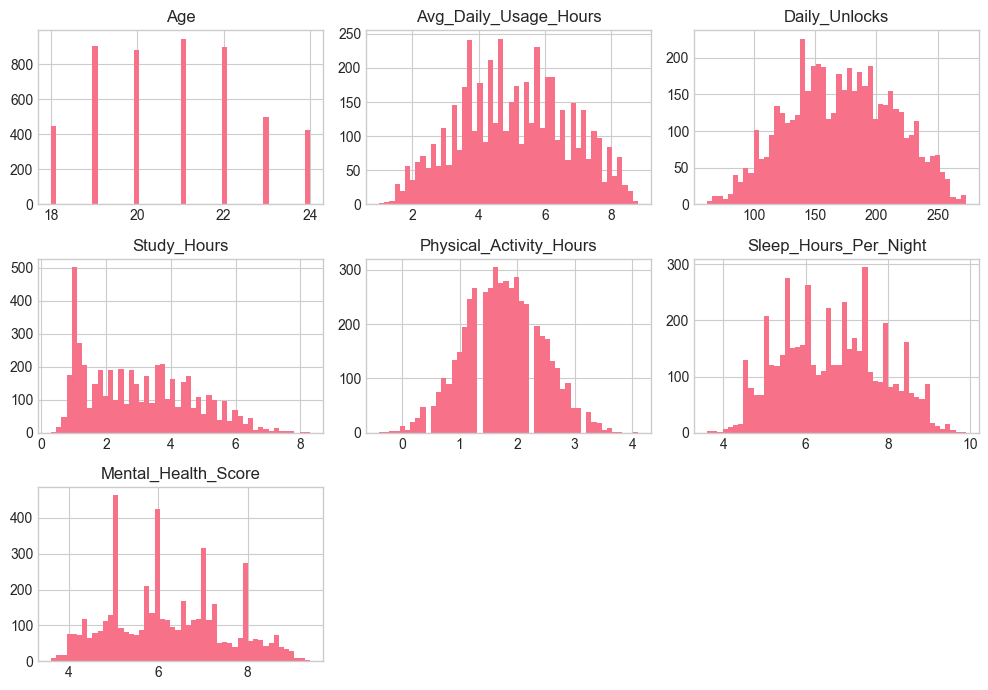

In [10]:
df.hist(figsize=(10, 7), bins=50)
plt.tight_layout()
plt.show()

## Correlation analysis
Check for redundant/highly correlated numerical features.

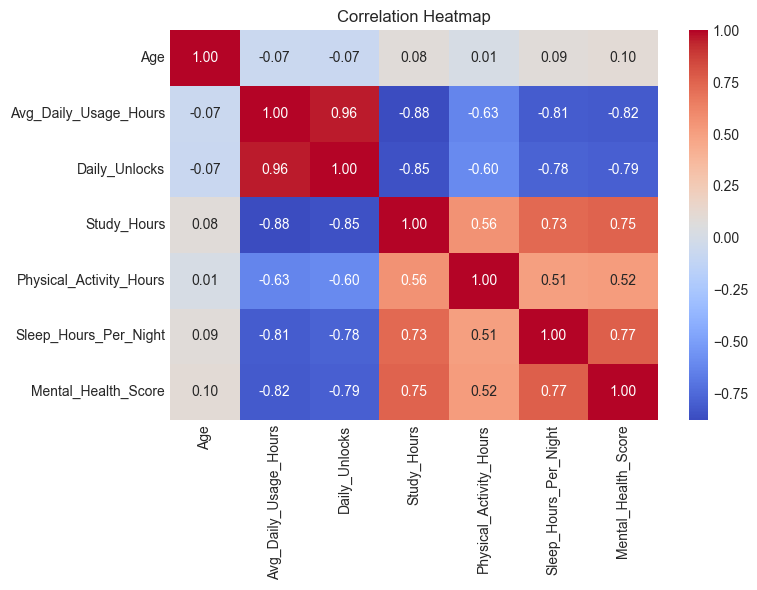

In [11]:
num = df.select_dtypes(include='number')
cor = num.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(cor, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Key findings from correlation
1. `Avg_Daily_Usage_Hours` and `Daily_Unlocks` are highly correlated - one is redundant for modeling and is dropped below.
2. `Stress_Level` shows a strong relationship with `Mental_Health_Score`. We keep it as a predictor since it is recorded independently (not derived from the target), but flag it for monitoring in production since it may itself be influenced by the same factors we're studying.

## Feature vs target relationships
Median/scatter plots of each feature against `Mental_Health_Score`.

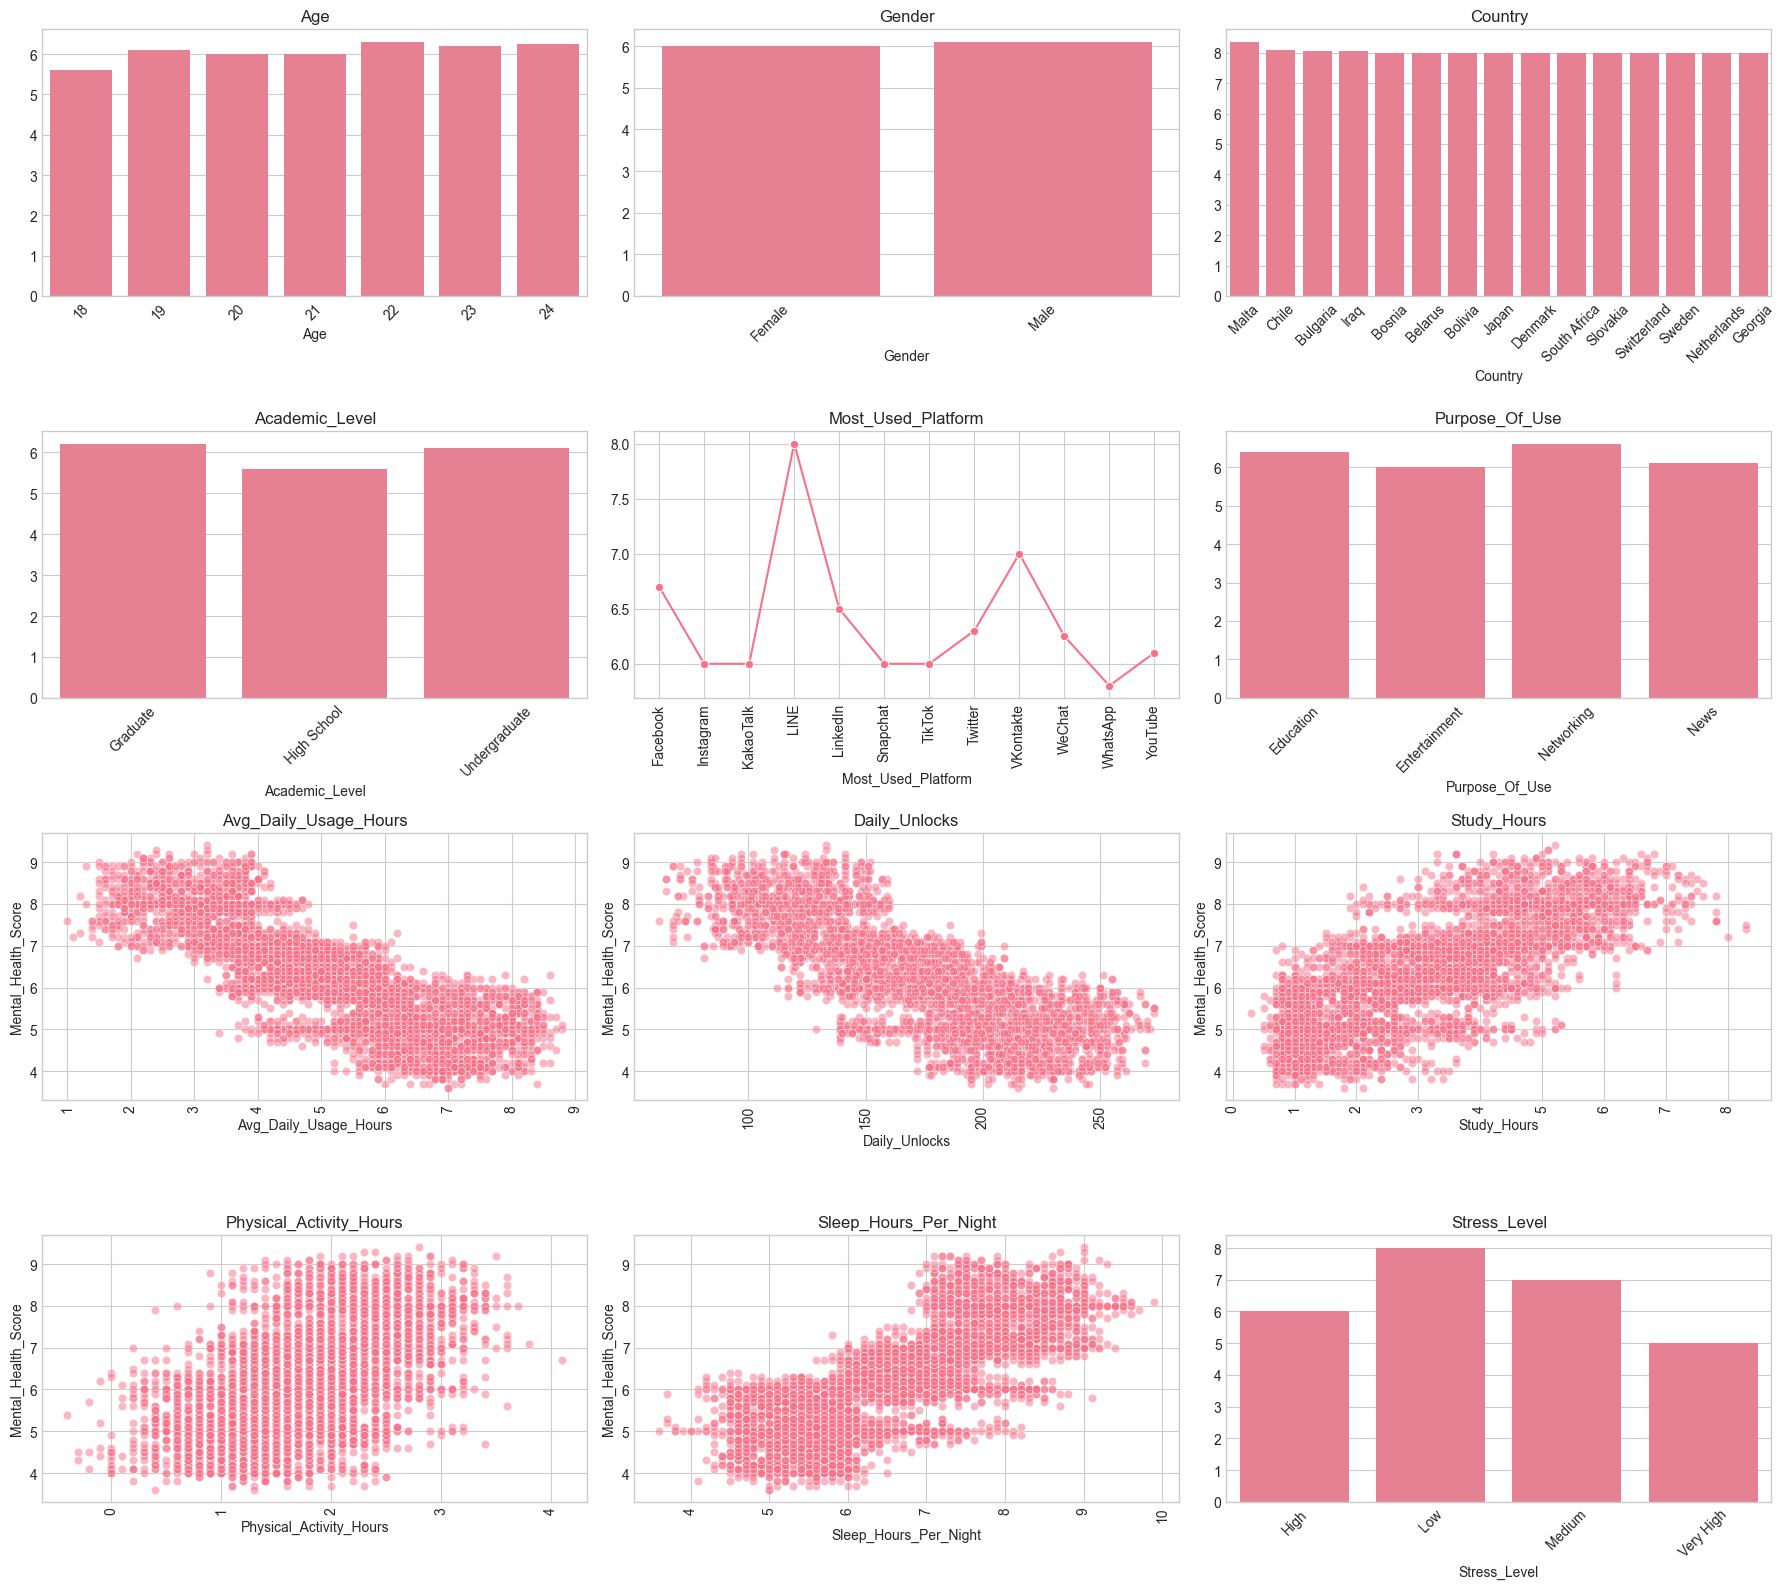

In [12]:
feature_cols = [c for c in df.columns if c != 'Mental_Health_Score']
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    n_unique = df[col].nunique()

    if n_unique <= 10:
        grouped = df.groupby(col)['Mental_Health_Score'].median()
        sns.barplot(x=grouped.index, y=grouped.values, ax=ax)
        ax.tick_params(axis='x', rotation=45)

    elif n_unique <= 30:
        grouped = df.groupby(col)['Mental_Health_Score'].median().sort_index()
        sns.lineplot(x=grouped.index, y=grouped.values, marker='o', ax=ax)
        ax.tick_params(axis='x', rotation=90)

    elif col == 'Country':
        grouped = (
            df.groupby('Country')['Mental_Health_Score']
            .median()
            .sort_values(ascending=False)
            .head(15)
        )
        sns.barplot(x=grouped.index, y=grouped.values, ax=ax)
        ax.tick_params(axis='x', rotation=45)

    else:
        sns.scatterplot(data=df, x=col, y='Mental_Health_Score', alpha=0.5, ax=ax)
        ax.tick_params(axis='x', rotation=90)

    ax.set_title(col)

# Hide any unused subplots
for ax in axes[len(feature_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Observations
- Sleep hours, physical activity hours, and study hours show a relationship with mental health score, generally following a "moderate is best" pattern.
- Daily unlocks and average usage hours trend negatively with the score.
- Demographic features (gender, academic level) show smaller differences in median score.

## Modeling pipeline
Build a preprocessing + model pipeline and compare candidate regressors. `Daily_Unlocks` is dropped (redundant with `Avg_Daily_Usage_Hours`).

In [13]:
X = df.drop(['Mental_Health_Score', 'Daily_Unlocks'], axis=1)
y = df['Mental_Health_Score']

categorical_cols = cat_col(X)
numerical_cols = num_col(X)

model_dict = {
    'DummyRegressor': DummyRegressor(strategy='mean'),
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(random_state=RANDOM_STATE),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

num_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

cat_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encode', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_cols),
    ('cat', cat_transformer, categorical_cols),
])

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE)),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

results = {}
for name, estimator in model_dict.items():
    clf.set_params(model=estimator)
    clf.fit(X_train, y_train)
    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)
    results[name] = {
        'R2_train': r2_score(y_train, train_pred),
        'R2_test': r2_score(y_test, test_pred),
        'MAE': mean_absolute_error(y_test, test_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
    }

results_df = pd.DataFrame(results).T
results_df

,R2_train,R2_test,MAE,RMSE
DummyRegressor,0.000000,-0.000594,1.127571,1.336514
LinearRegression,0.782209,0.789245,0.475852,0.613385
RandomForestRegressor,0.986132,0.913288,0.281401,0.393445
GradientBoostingRegressor,0.845380,0.844409,0.408648,0.527032


The Random Forest and Gradient Boosting models substantially outperform the baseline and linear model. Random Forest is selected as the candidate for cross-validation and tuning.

## Cross-validation
Compare models using 3-fold cross-validation on R² (fixes original bug where the CV results dict was never converted to a usable DataFrame).

In [14]:
cv_results = {}
for name, estimator in model_dict.items():
    clf.set_params(model=estimator)
    cv_results[name] = cross_val_score(clf, X, y, cv=3, scoring='r2')

cv_df = pd.DataFrame(cv_results)
cv_df

,DummyRegressor,LinearRegression,RandomForestRegressor,GradientBoostingRegressor
0,-0.000101,0.790807,0.921894,0.849421
1,-0.000846,0.778192,0.905184,0.834097
2,-0.000352,0.769030,0.888703,0.823047


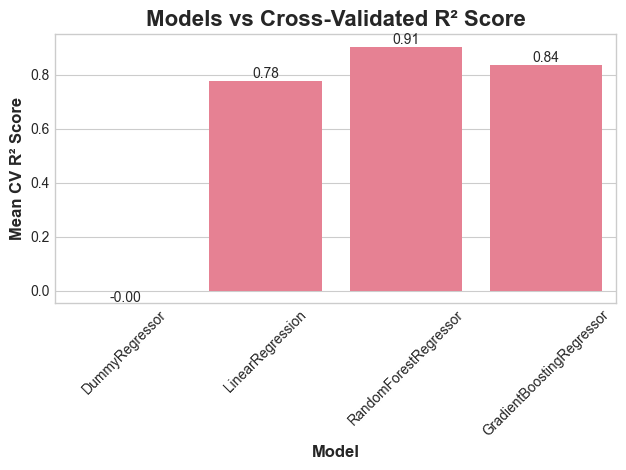

In [15]:
ax = sns.barplot(data=cv_df.mean().reset_index(), x='index', y=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title('Models vs Cross-Validated R² Score', fontweight='bold', fontsize=16)
plt.xlabel('Model', fontweight='bold', fontsize=12)
plt.ylabel('Mean CV R² Score', fontweight='bold', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Random Forest shows the strongest and most stable cross-validated R², confirming it as the best candidate model.

## Feature importance and residual analysis
Fit the Random Forest on the training set and inspect feature importances and residuals (fixes original bug: `importances` was referenced but never created).

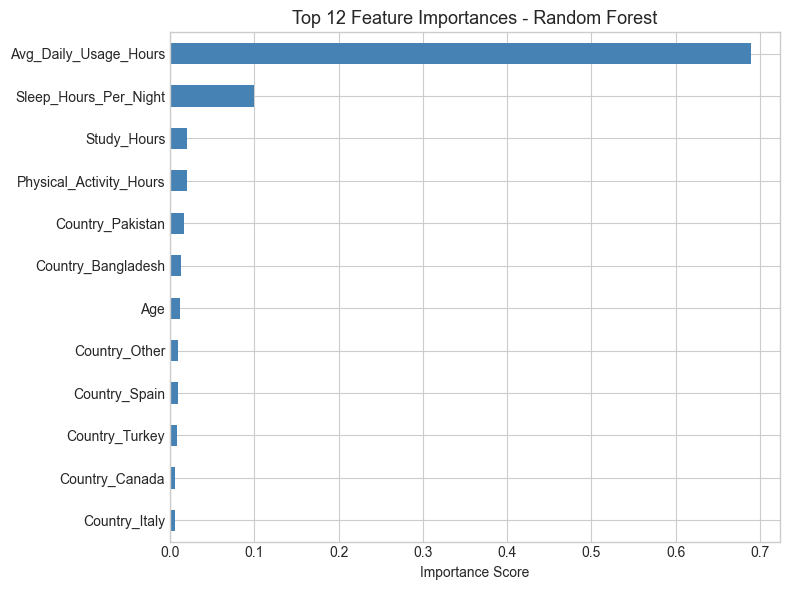

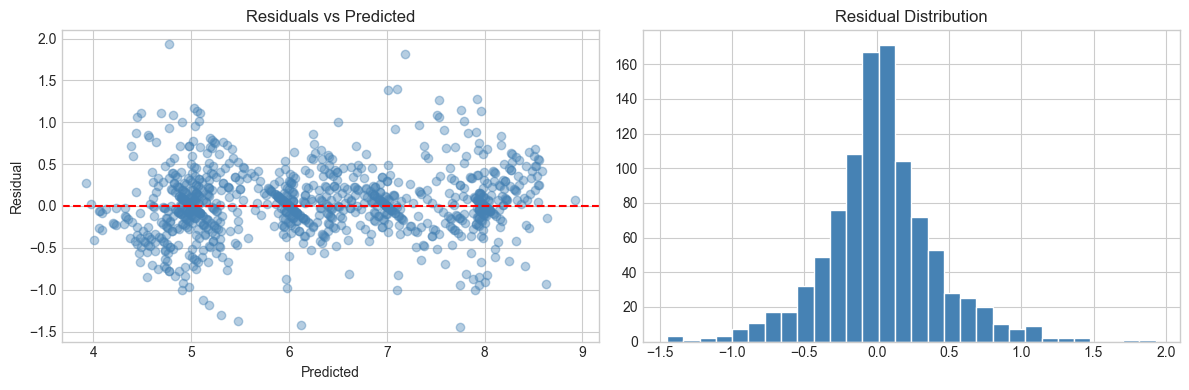

In [16]:
clf.set_params(model=RandomForestRegressor(random_state=RANDOM_STATE))
clf.fit(X_train, y_train)

rf = clf.named_steps['model']
pr = clf.named_steps['preprocessor']

feature_names = pr.get_feature_names_out()
feature_names = [f.split('__')[-1] for f in feature_names]

weights = rf.feature_importances_

importances = pd.Series(weights, index=feature_names).sort_values(ascending=False).head(12)

best_pred = clf.predict(X_test)
residuals = y_test - best_pred

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 12 Feature Importances - Random Forest', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(best_pred, residuals, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

## Hyperparameter tuning
Use `RandomizedSearchCV` to tune the Random Forest, then refit the final pipeline with the best parameters.



In [17]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
}

clf.set_params(model=RandomForestRegressor(random_state=RANDOM_STATE))

search = RandomizedSearchCV(
    clf,
    param_grid,
    n_iter=10,
    cv=3,
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV R2:", round(search.best_score_, 4))

# Refit the final pipeline on ALL training data with the best parameters
final_model = search.best_estimator_
final_pred = final_model.predict(X_test)

print("Test R2:", r2_score(y_test, final_pred))
print("Test MAE:", mean_absolute_error(y_test, final_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, final_pred)))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 20}
Best CV R2: 0.8798
Test R2: 0.9116308325260416
Test MAE: 0.2845915060140725
Test RMSE: 0.3971868060081014


## Export model for deployment
Save the final tuned pipeline (preprocessing + model) so it can be loaded directly in a production service without re-running training.

In [21]:
MODEL_PATH = '../models/model_v1.joblib'
joblib.dump(final_model, MODEL_PATH)
print(f"Model saved to '{MODEL_PATH}'")

Model saved to '../models/model_v1.joblib'


## Inference function
A simple function for serving predictions, e.g. from an API endpoint. It validates required columns and returns a predicted score.

In [20]:
REQUIRED_COLUMNS = list(X.columns)

def predict_mental_health_score(input_dict, model=None, model_path=MODEL_PATH):
    """Predict Mental_Health_Score from a dict of feature values.

    Parameters
    ----------
    input_dict : dict
        Must contain all columns in REQUIRED_COLUMNS.
    model : fitted pipeline, optional
        If not provided, loads from `model_path`.
    """
    if model is None:
        model = joblib.load(model_path)

    missing = set(REQUIRED_COLUMNS) - set(input_dict.keys())
    if missing:
        raise ValueError(f"Missing required fields: {sorted(missing)}")

    input_df = pd.DataFrame([input_dict])[REQUIRED_COLUMNS]
    prediction = model.predict(input_df)[0]
    return float(np.clip(prediction, 0, 100))


# Example usage
example = X_test.iloc[0].to_dict()
print("Example input:", example)
print("Predicted Mental_Health_Score:", predict_mental_health_score(example, model=final_model))

Example input: {'Age': 18, 'Gender': 'Male', 'Country': 'India', 'Academic_Level': 'High School', 'Most_Used_Platform': 'TikTok', 'Purpose_Of_Use': 'Entertainment', 'Avg_Daily_Usage_Hours': 8.4, 'Study_Hours': 1.0, 'Physical_Activity_Hours': 1.4, 'Sleep_Hours_Per_Night': 5.9, 'Stress_Level': 'Very High'}
Predicted Mental_Health_Score: 4.899213606981256


# Suggestions
Students should aim for moderate, intentional social media use rather than extended unstructured scrolling. Maintaining a consistent sleep schedule (roughly 7-8 hours) appears strongly associated with better mental health scores. Moderate study time (around 4-6 hours) is associated with the best outcomes - both very low and very high study hours correlate with lower scores, possibly reflecting disengagement or burnout respectively.

# Conclusion
Students with balanced sleep (around 7-8 hours/night), moderate social media usage, regular physical activity, and a moderate study load (4-6 hours/day) tend to report the highest Mental Health Scores. Excessive social media usage and sleep deprivation are the strongest negative predictors. The tuned Random Forest pipeline achieves a strong test R² and has been exported (`mental_health_score_model.joblib`) along with a reusable inference function for deployment.

# Limitations & next steps
- This is an observational dataset; relationships described are correlational, not causal.
- `Stress_Level` may partially encode information related to the target and should be monitored for drift/leakage in production.
- Recommend periodic retraining as new data becomes available, and adding input validation/logging in the deployed service.